TEMP avant envoi vers code

# d'après le chapitre Arima du livre Hyndman

In [1]:
import pandas as pd

######### TEMP ###########
# lecture de steam_prod d'inariz 
# sera enlevé quand on connectera les différents bouts ensemble
from src.ingest import data_workflow

list_df = []
for filename in [
    "inariz_steam_prod_2026-03-09_to_2026-03-12.csv",
    "inariz_steam_prod_2026-03-13_to_2026-03-16.csv",
]:
    df = data_workflow("inariz", "steam_prod", filename)

    # include the unit into the main column name
    df = df.rename(columns={"Valeur": "steam_production_m3_h"})

    list_df.append(df)

steam_prod = pd.concat(list_df, ignore_index=True)

# for other columns, keep only numerical columns
# set the timestamp as a column with a standard name, not as the index
steam_prod = steam_prod.drop(columns=["Unité"])

# target
steam_prod = steam_prod[
    ["measured_at_utc", "steam_production_m3_h"]
]

from src.dataset import resample
df_15min = resample(steam_prod, desired_timedelta="15min", aggregate_function="mean")
# fill the nan values with a 0
df_15min["steam_production_m3_h"] = df_15min["steam_production_m3_h"].fillna(0)

In [2]:
# contrôles visuels : 
# le plot de la time serie
# le plot ACF. Pour une série stationnaire, il tombera à 0 assez vite, alors que ça décroiera lentement sinon.
# et pour une série non-stationnaire, la valeur de r_1 est souvent grande et positive.



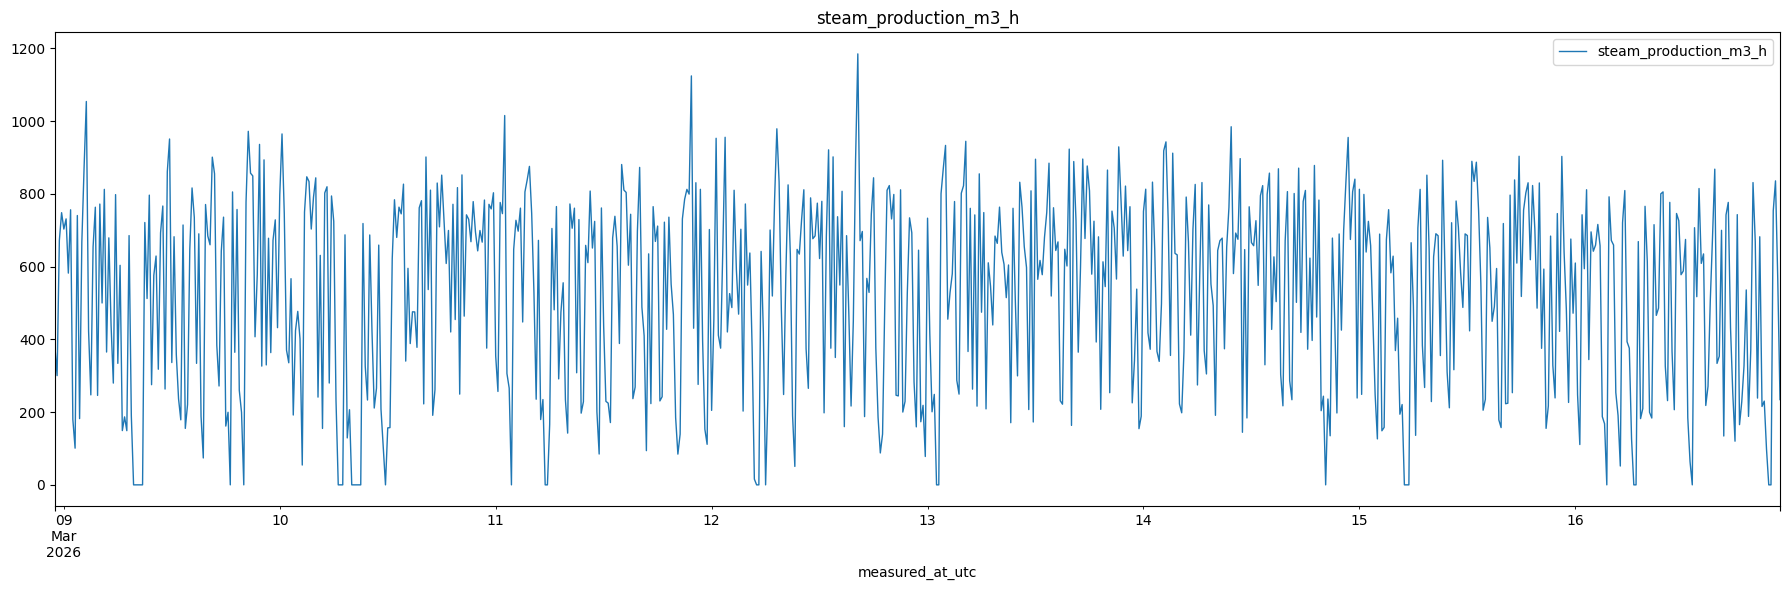

In [3]:
# plot de la time serie

import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))

# boiler box
ax = df_15min.plot("measured_at_utc", y="steam_production_m3_h", linewidth=1, ax=ax)
ax.set_title("steam_production_m3_h")
ax.set_xlabel("measured_at_utc")

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [4]:
# temp : observer les creux, pour savoir s'il faut remplir avec du 0, ou de l'interpolation, ou copier la valeur précédente, etc.
steam_prod[(steam_prod["measured_at_utc"]>pd.Timestamp(2026, 3, 9, 7, 27, 0, tz= "UTC"))&(steam_prod["measured_at_utc"]<pd.Timestamp(2026, 3, 9, 9, 8, 0, tz= "UTC"))]

,measured_at_utc,steam_production_m3_h
2579,2026-03-09 07:27:04.019000+00:00,376.532684
2580,2026-03-09 07:33:20.018000+00:00,274.820282
2581,2026-03-09 07:35:23.008000+00:00,171.212219
2582,2026-03-09 07:35:48.001000+00:00,271.676422
2583,2026-03-09 07:43:55.014000+00:00,167.980667
2584,2026-03-09 07:44:26.006000+00:00,66.796349
2585,2026-03-09 09:07:37.020000+00:00,173.640518
2586,2026-03-09 09:07:41.006000+00:00,277.586212
2587,2026-03-09 09:07:47.018000+00:00,379.411652


In [5]:
# temp : observer les creux, pour savoir s'il faut remplir avec du 0, ou de l'interpolation, ou copier la valeur précédente, etc.
df_15min[(df_15min["measured_at_utc"]>pd.Timestamp(2026, 3, 9, 7, 25, 0, tz= "UTC"))&(df_15min["measured_at_utc"]<pd.Timestamp(2026, 3, 9, 9, 8, 0, tz= "UTC"))]

,measured_at_utc,steam_production_m3_h
34,2026-03-09 07:30:00+00:00,190.497188
35,2026-03-09 07:45:00+00:00,0.000000
36,2026-03-09 08:00:00+00:00,0.000000
37,2026-03-09 08:15:00+00:00,0.000000
38,2026-03-09 08:30:00+00:00,0.000000
39,2026-03-09 08:45:00+00:00,0.000000
40,2026-03-09 09:00:00+00:00,721.073953


In [6]:
pd.Timestamp(2026, 3, 8, 23, 8, 0, tz= "UTC")

Timestamp('2026-03-08 23:08:00+0000', tz='UTC')

In [7]:
pd.Timestamp(2026, 3, 8, 23, 8, 0, tz= "UTC").floor(freq="15min")

Timestamp('2026-03-08 23:00:00+0000', tz='UTC')

In [39]:
# temp tentative meilleure forme d'agregation/resample
# 1. créer les index manquants aux frontières des intervales de 15min
# 2. y copier la valeur précédentes

#tester ce que m'a fait codex TEMP
from src.dataset import add_missing_timestamps_with_previous_value

df_reindexed = add_missing_timestamps_with_previous_value(steam_prod)
df_reindexed[(df_reindexed["measured_at_utc"]>pd.Timestamp(2026, 3, 9, 7, 27, 0, tz= "UTC"))&(df_reindexed["measured_at_utc"]<pd.Timestamp(2026, 3, 9, 9, 8, 0, tz= "UTC"))]


,measured_at_utc,steam_production_m3_h
2612,2026-03-09 07:27:04.019000+00:00,376.532684
2613,2026-03-09 07:30:00+00:00,376.532684
2614,2026-03-09 07:33:20.018000+00:00,274.820282
2615,2026-03-09 07:35:23.008000+00:00,171.212219
2616,2026-03-09 07:35:48.001000+00:00,271.676422
2617,2026-03-09 07:43:55.014000+00:00,167.980667
2618,2026-03-09 07:44:26.006000+00:00,66.796349
2619,2026-03-09 07:45:00+00:00,66.796349
2620,2026-03-09 08:00:00+00:00,66.796349
2621,2026-03-09 08:15:00+00:00,66.796349


In [35]:

from src.dataset import equivalent_constant_rate_on_15min
# temp tenter ce qu'a fait CODEX

# 3. prendre la valeur ocnstante qui donne la meme aire sous la courbe

# 2) area under curve on each interval + attribution to 15-min bins
eq_15min = equivalent_constant_rate_on_15min(
    df_reindexed,
    timestamp_col="measured_at_utc",
    value_col="steam_production_m3_h",
    freq="15min",
)

eq_15min[(eq_15min["measured_at_utc"]>pd.Timestamp(2026, 3, 9, 7, 27, 0, tz= "UTC"))&(eq_15min["measured_at_utc"]<pd.Timestamp(2026, 3, 9, 9, 8, 0, tz= "UTC"))]

# # resampled_df = eq_15min[["bin_start", "equivalent_steam_production_m3_h"]].drop_duplicates().reset_index()

# resampled_df
final_df = eq_15min[["bin_start", "equivalent_steam_production_m3_h"]].drop_duplicates()
final_df = final_df.dropna().reset_index()
final_df

,index,bin_start,equivalent_steam_production_m3_h
0,1,2026-03-08 23:00:00+00:00,290.441258
1,104,2026-03-08 23:15:00+00:00,267.124525
2,195,2026-03-08 23:30:00+00:00,371.020334
3,260,2026-03-08 23:45:00+00:00,228.311791
4,313,2026-03-09 00:00:00+00:00,569.235351
...,...,...,...
763,57326,2026-03-16 21:45:00+00:00,50.073009
764,57327,2026-03-16 22:00:00+00:00,195.098763
765,57372,2026-03-16 22:15:00+00:00,751.234990
766,57446,2026-03-16 22:30:00+00:00,638.338393


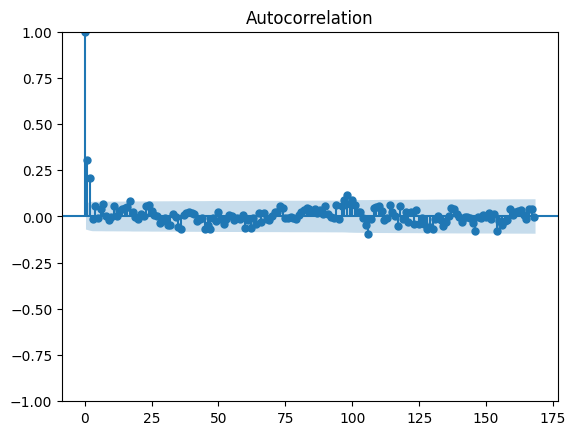

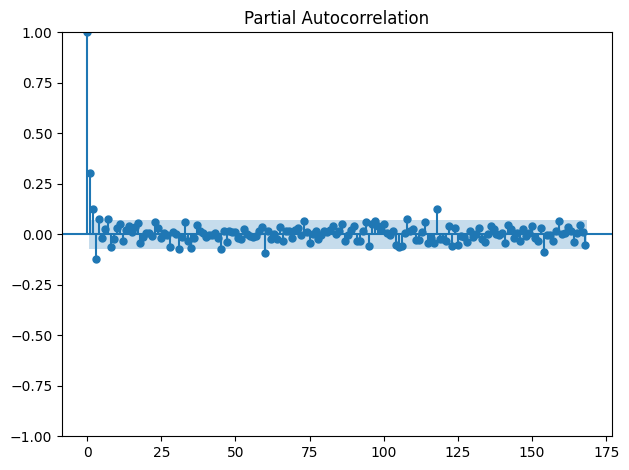

In [36]:
# plot ACF of initial data

from plots import autocorrelation_plot #plot_acf y fait ce que je veux, mais que fait pacf?

autocorrelation_plot(final_df, "equivalent_steam_production_m3_h")

# faire la meme chose avec bartlett_confint=False comme dans hyndman?

le plot d'autocorrelation ci-dessus pour les données initiales tend à indiquer qu'on a une série NON-stationnaire

In [ ]:
# vérification avec la stat de Ljung-Box
# permet de savoir si les points successifs sont aléatoires et indépendants, ou pas.

from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(df_15min["steam_production_m3_h"], lags=[10])
ljung_box

# si la p-value est très faible, alors il y a correlation

,lb_stat,lb_pvalue
10,54.880544,3.324532e-08


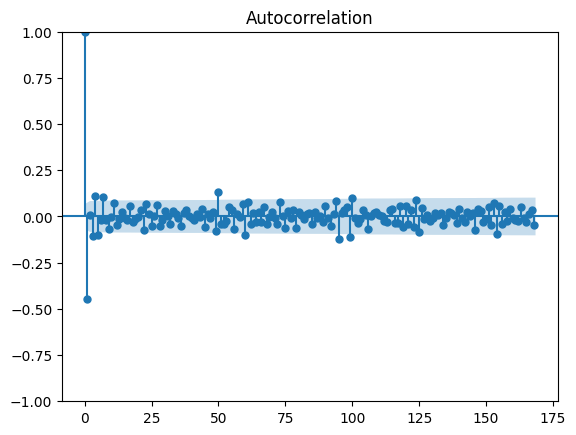

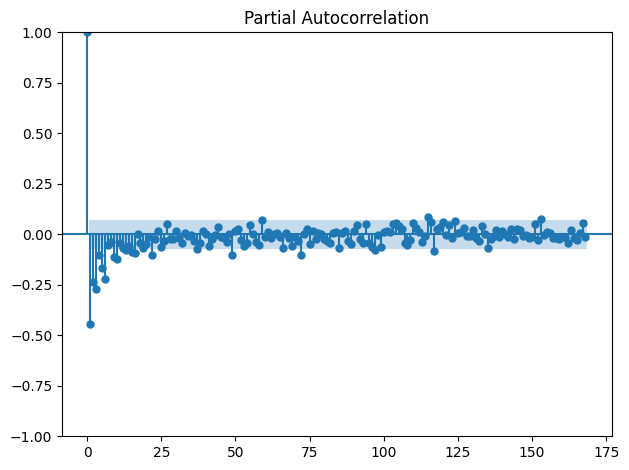

In [ ]:
# plot ACF of the differentiated data
steam_prod_diff = df_15min.copy()
steam_prod_diff["steam_production_m3_h"] = steam_prod_diff["steam_production_m3_h"].diff()

autocorrelation_plot(steam_prod_diff[1:], "steam_production_m3_h")

je ne suis pas sûr de ce que nous dit le plot d'autocorrelation ci-dessus pour la donnée différentiée.
D'un côté la décroissance immédiate vers 0 tend à indiquer que la donnée différentiée est BIEN stationnaire
De l'autre la première valeur demeure élevée et positive.

In [ ]:
# vérification avec la stat de Ljung-Box
# permet de savoir si les points successifs sont aléatoires et indépendants, ou pas.

ljung_box = acorr_ljungbox(steam_prod_diff["steam_production_m3_h"][1:], lags=[10])
ljung_box

# si la p-value est très faible, alors il y a correlation

,lb_stat,lb_pvalue
10,191.476866,9.633720e-36


In [ ]:
len(steam_prod_diff)

768

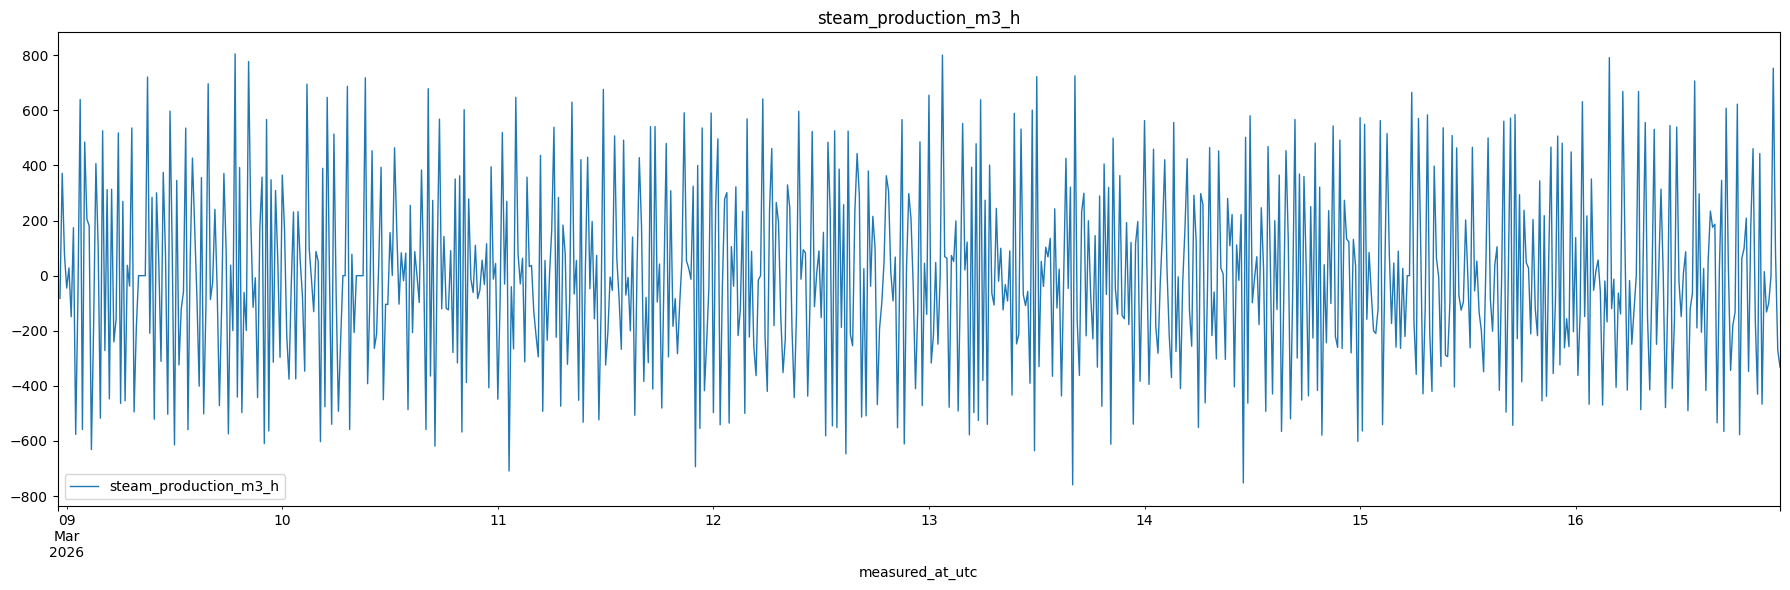

In [ ]:
# besoin de faire du second-order differencing ? seul, ou en plus du first-order?
# ou du seasonal differencing ? seul, ou en plus du first order ?

# contrôle visuel de ce que donne la donnée différentiée une fois.
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(18, 6))

ax = steam_prod_diff[:1000].plot("measured_at_utc", y="steam_production_m3_h", linewidth=1, ax=ax)
ax.set_title("steam_production_m3_h")
ax.set_xlabel("measured_at_utc")

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

on ne voit pas encore un bruit blanc dans le signal différentié ci-dessus, ça donne envie de tester de faire une double différentiation.

In [ ]:
# unit root test, pour savoir si la donnée est stationnaire, pour tester l'hypothèse de stationnarité
# adf test : augmented dickey fuller test
# Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test (dans livre hyndman)

# kpss
from statsmodels.tsa.stattools import kpss
kpss_stat, kpss_pvalue, lags, crit = kpss(df_15min["steam_production_m3_h"], nlags = 5)
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}") #between 0.01 and 0.1. If less than 0.01, reported as 0.01. If more than 0.1, reported as 0.1. 
#If kpss_pvalue is small (<0.05), the data is not stationary
print(lags)
print(crit)

kpss_stat: 0.203
kpss_pvalue: 0.10
5
{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_41084\4168445975.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, lags, crit = kpss(df_15min["steam_production_m3_h"], nlags = 5)


for kpss, the small p value indicates that there is no stationarity.

In [ ]:
# adf # augmented dickey fullre
from statsmodels.tsa.stattools import adfuller
adfuller_stat, adfuller_pvalue, usedlag, nobs, critical_values, *_ = adfuller(df_15min["steam_production_m3_h"])
print(f"adfuller_stat: {adfuller_stat:.3f}")
print(f"adfuller_pvalue: {adfuller_pvalue}") #between 0 and 1. If <= 0.05, then strong evidence that data is stationary
print(f"usedlag: {usedlag:.3f}")
print(f"nobs: {nobs:.3f}")

print('Critical Values:')
    #labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
for key, value in critical_values.items():
    print('\t%s: %.3f' % (key, value))

# check of the very small value
print(repr(adfuller_pvalue))
print(f"{adfuller_pvalue:.20e}")



adfuller_stat: -8.656
adfuller_pvalue: 4.972497682625203e-14
usedlag: 6.000
nobs: 761.000
Critical Values:
	1%: -3.439
	5%: -2.865
	10%: -2.569
np.float64(4.972497682625203e-14)
4.97249768262520305670e-14


if the p value i still displayed as 0, it means that it is even smaller than machine/reporting precision.

for ADF, the small p-value suggests there IS stationarity.


In [ ]:

# kpss of the differenced data
kpss_stat, kpss_pvalue, *_ = kpss(steam_prod_diff["steam_production_m3_h"][1:], nlags = 5)
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}") #between 0.01 and 0.1. If less than 0.01, reported as 0.01. If more than 0.1, reported as 0.1. 
#If kpss_pvalue is small (<0.05), the data is not stationary



kpss_stat: 0.007
kpss_pvalue: 0.10


C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_41084\3342558145.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(steam_prod_diff["steam_production_m3_h"][1:], nlags = 5)


In [ ]:
# adf of the differenced data
adfuller_stat, adfuller_pvalue, usedlag, nobs, critical_values, *_ = adfuller(steam_prod_diff["steam_production_m3_h"][1:])
print(f"adfuller_stat: {adfuller_stat:.3f}")
print(f"adfuller_pvalue: {adfuller_pvalue}") #between 0 and 1. If <= 0.05, then strong evidence that data is stationary
print(f"usedlag: {usedlag:.3f}")
print(f"nobs: {nobs:.3f}")

print('Critical Values:')
    #labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
for key, value in critical_values.items():
    print('\t%s: %.3f' % (key, value))

# check of the very small value
print(repr(adfuller_pvalue))
print(f"{adfuller_pvalue:.20e}")

adfuller_stat: -12.244
adfuller_pvalue: 9.873418457633759e-23
usedlag: 15.000
nobs: 751.000
Critical Values:
	1%: -3.439
	5%: -2.865
	10%: -2.569
np.float64(9.873418457633759e-23)
9.87341845763375930123e-23


Pour la série différentiée ci dessus, on a le test kpss qui valide l'hypothèse de stationnarité, et le test adf qui rejette l'hypothèse de unit root, ce qui laisse la place à la stationnarité.
Donc en effet on peut être bien avec la série différentiée !

In [ ]:
# do the successive kpss alone, and return the number of appropriate first differences:
from statsforecast.arima import ndiffs
ndiffs(df_15min["steam_production_m3_h"].to_numpy())



c:\Users\Loris Amabile\Documents\c_market\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0

je ne comprends pas, pourquoi ndiffs ça dit 0 differences à faire, alors que moi en en faisant une et en vérifiant avec kpss, je suis bien ?

In [ ]:
# quick way to verify apples to apples, from codex
import math
import numpy as np
import statsmodels.api as sm
from statsforecast.arima import ndiffs

x = df_15min["steam_production_m3_h"].to_numpy()

print("ndiffs:", ndiffs(x))
nl0 = math.floor(3 * math.sqrt(len(x)) / 13)
print("kpss level (same lag rule):", sm.tsa.kpss(x, "c", nlags=nl0)[1])

xd = np.diff(x)
nl1 = math.floor(3 * math.sqrt(len(xd)) / 13)
print("kpss diff1 (same lag rule):", sm.tsa.kpss(xd, "c", nlags=nl1)[1])


ndiffs: 0
kpss level (same lag rule): 0.1
kpss diff1 (same lag rule): 0.1


C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_41084\13614258.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("kpss level (same lag rule):", sm.tsa.kpss(x, "c", nlags=nl0)[1])
C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_41084\13614258.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("kpss diff1 (same lag rule):", sm.tsa.kpss(xd, "c", nlags=nl1)[1])


In [ ]:
## je continue l'apple to apple, adapté moi meme : 
# nlags calculés par moi meme, et kpss utilisé comme initialement. 
# J'obtiens 0.1 cette fois ?
x = df_15min["steam_production_m3_h"].to_numpy()
nl0 = math.floor(3 * math.sqrt(len(x)) / 13)

kpss_stat, kpss_pvalue, *_ = kpss(df_15min["steam_production_m3_h"], nlags = nl0)
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}") #between 0.01 and 0.1. If less than 0.01, reported as 0.01. If more than 0.1, reported as 0.1. 
#If kpss_pvalue is small (<0.05), the data is not stationary

kpss_stat: 0.199
kpss_pvalue: 0.10


C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_41084\3386110329.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(df_15min["steam_production_m3_h"], nlags = nl0)


donc en effet, le choix de nlags change la pvalue de kpss.
1. comprendre le choix de 5 comme nlags par hyndman
2. est ce que je peux changer le nlags de ndiffs de statsforecast? => non
3. quel est l'impact des lags dans kpss? 
- plus de lags ajoute des termes d'autocovariance dans l'estimateur de la variance
- plus on rajoute de lags, plus on augmente l'estimateur de la variance, plus on va probablement diminuer la valeur de la stat et augmenter la pvalue, plus on accepter la stationnarité.
- si on prend peu de lags, on sous estime la variance longterme, on rejette trop souvent l'hypothèse de stationarité.

LM : lagrange multiplier
LBI : locally best invariant


In [ ]:
# je ne comprends pas le choix de nlags par hyndman, mais je peux appeler kpss avec la vlaeur par défaut nlags auto
kpss_stat, kpss_pvalue, lags, crit = kpss(df_15min["steam_production_m3_h"], nlags="auto")
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}") #between 0.01 and 0.1. If less than 0.01, reported as 0.01. If more than 0.1, reported as 0.1. 
#If kpss_pvalue is small (<0.05), the data is not stationary
print(lags)
print(crit)

kpss_stat: 0.186
kpss_pvalue: 0.10
9
{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_41084\695820153.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, lags, crit = kpss(df_15min["steam_production_m3_h"], nlags="auto")


donc il y aurait DEJA de la stationnarité dans la donné initiale ? 

In [ ]:
# etudier l'évolution des résultats de kpss en fonction des lags
nl0 = math.floor(3 * math.sqrt(len(x)) / 13)
nl0


6

In [ ]:

kpss_results = []
for nlags in range(55):
    results = kpss(df_15min["steam_production_m3_h"], nlags=nlags)
    kpss_results.append(results)

kpss_results_df = pd.DataFrame(kpss_results, columns=["kpss_stat", "p_value", "lags", "crit"] )
kpss_results_df
#{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_41084\2661416234.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  results = kpss(df_15min["steam_production_m3_h"], nlags=nlags)
C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_41084\2661416234.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  results = kpss(df_15min["steam_production_m3_h"], nlags=nlags)
C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_41084\2661416234.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  results = kpss(df_15min["steam_production_m3_h"], nlags=nlags)
C:\Users\Loris Amabile\AppData\Local\Temp\ipykernel_41084\2661416234.py:3: Inte

,kpss_stat,p_value,lags,crit
0,0.309810,0.1,0,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
1,0.258652,0.1,1,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
2,0.231824,0.1,2,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
3,0.219830,0.1,3,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
4,0.208726,0.1,4,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
5,0.203426,0.1,5,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
6,0.199219,0.1,6,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
7,0.193126,0.1,7,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
8,0.188322,0.1,8,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."
9,0.185725,0.1,9,"{'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%..."


In [ ]:
# # do the successive ?? alone, and return the number of appropriate seasonal differences
# # based on the seasonal strength
# from statsforecast.arima import nsdiffs
# # Test for seasonal differencing
# nsdiffs(df_15min["steam_production_m3_h"], period=12)
# # nous on peut tester avec ces périodes_là : un jour (on n'a pas une semaine dans ce dataset limité chargé ici) 

# je ne fais meme pas le seasonal differencing avec nsdiffs, car d'après mon test KPSS avec les lags qu'on m'impose, j'ai déjà de la stationnarité !


In [ ]:
df_15min[:10]

,measured_at_utc,steam_production_m3_h
0,2026-03-08 23:00:00+00:00,382.678980
1,2026-03-08 23:15:00+00:00,300.257193
2,2026-03-08 23:30:00+00:00,671.553951
3,2026-03-08 23:45:00+00:00,748.099304
4,2026-03-09 00:00:00+00:00,703.072318
5,2026-03-09 00:15:00+00:00,731.032826
6,2026-03-09 00:30:00+00:00,582.006044
7,2026-03-09 00:45:00+00:00,756.045527
8,2026-03-09 01:00:00+00:00,179.773505
9,2026-03-09 01:15:00+00:00,100.852229


In [ ]:

# differencing : une façon de transformer une série non-stationnaire en série temporelle stationnaire


In [ ]:
# modèles de base à faire et évaluer : autorégression simple, et moving average simple

In [ ]:
# temp pour capter la forme du df

egyptian_economy = (
    pd.read_csv(r"C:\Users\Loris Amabile\Downloads\global_economy.csv", parse_dates=[2])
    .rename(columns={"Exports": "y"})
    .loc[lambda x: x["Code"] == "EGY"]
    [["ds", "y", "unique_id"]]
)

egyptian_economy

,ds,y,unique_id
3770,1960-01-01,19.866193,"Egypt, Arab Rep."
3771,1961-01-01,17.646307,"Egypt, Arab Rep."
3772,1962-01-01,15.052380,"Egypt, Arab Rep."
3773,1963-01-01,17.758857,"Egypt, Arab Rep."
3774,1964-01-01,18.398046,"Egypt, Arab Rep."
3775,1965-01-01,17.130876,"Egypt, Arab Rep."
3776,1966-01-01,16.333374,"Egypt, Arab Rep."
3777,1967-01-01,16.825785,"Egypt, Arab Rep."
3778,1968-01-01,11.799921,"Egypt, Arab Rep."
3779,1969-01-01,13.452832,"Egypt, Arab Rep."


In [ ]:
# utiliser AutoARIMA() de statsforecast décidera tout seul des valeurs de p, d, q à choisir

from statsforecast.arima import ARIMASummary
from statsforecast.models import AutoARIMA
from statsforecast import StatsForecast

models = [AutoARIMA(allowmean=True)]
sf = StatsForecast(models=models, freq="A", n_jobs=-1)
sf.fit(df=df_15min)

model = sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs["mean"] = coefs.pop("intercept")
coefs = {k: round(v, 3) for k, v in coefs.items()}
coefs = pd.Series(coefs, name="Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

KeyError: 'ds'

In [ ]:

# en calculer le prediction interval (l'intervalle de confiance)
# est-ce que les résidus du modèle ARIMA sont distribués normalement et non correlé ?
# Si oui, on peut calculer la variance présente au pas n de la prévision. Ca suivrait alors une loi normale.
# si non, on peut plutot adapter la méthode ARIMA. Au lieu de créer un forecast d'un point, générer des "sample paths".
## l'idée : au lieu de remplacer les erreurs futures par 0, les remplacer par un tirage **bootstrap** de la distribution empirique des résidus passés. Voir le livre Hyndman sur la partie toolbox > bootstrap
